# AISO v2 — Fitness-Weighted Partner Selection

## 핵심 변경
| | AISO (원본) | AISO_v2 |
|---|---|---|
| **파트너 선택** | uniform random | softmax(aS) 비례 |
| **수식 구조** | 동일 | 동일 |
| **타입 업데이트** | 동일 | 동일 |

`j ~ softmax(τ · aS)` — τ(temperature)로 탐색/활용 균형 조절

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

N_AGENTS = 30
N_ITER   = 200
ALPHA    = 0.3
BETA     = 0.1
N_RUNS   = 5
SEEDS    = [42, 123, 777, 2024, 31415]

PSO_W, PSO_C1, PSO_C2   = 0.729, 1.494, 1.494
FA_BETA0, FA_GAMMA, FA_ALPHA_FA = 1.0, 1.0, 0.2
DE_F, DE_CR              = 0.8, 0.9

COLORS = {
    'AISO':        '#DD8452',
    'AISO_v2_t1':  '#FF6B35',
    'AISO_v2_t5':  '#C0392B',
    'AISO_v2_t10': '#8B0000',
    'PSO':         '#4C72B0',
    'Firefly':     '#C44E52',
    'DE':          '#55A868',
    'Random':      '#8C8C8C',
}
print('설정 완료')

설정 완료


In [2]:
# ================================================================
# 벤치마크 함수
# ================================================================
def make_rastrigin(K, A=10):
    def f(X): x=X*10.24-5.12; return -(A*K+np.sum(x**2-A*np.cos(2*np.pi*x)))
    return f

def make_rosenbrock(K):
    def f(X): x=X*4.0-2.0; return -np.sum(100*(x[1:]-x[:-1]**2)**2+(1-x[:-1])**2)
    return f

def make_schwefel(K):
    lo, hi = -500.0, 500.0
    def f(X):
        x = X*(hi-lo)+lo
        return -(418.9829*K - np.sum(x*np.sin(np.sqrt(np.abs(x)))))
    return f

def make_griewank(K):
    lo, hi = -600.0, 600.0
    def f(X):
        x = X*(hi-lo)+lo
        s = np.sum(x**2)/4000
        p = np.prod(np.cos(x/np.sqrt(np.arange(1,K+1))))
        return -(s - p + 1)
    return f

def make_noisy(base_f, sigma=2.0):
    def f(X): return base_f(X) + np.random.normal(0, sigma)
    return f

def make_ackley(K):
    lo, hi = -32.768, 32.768
    def f(X):
        x = X*(hi-lo)+lo
        a = -20*np.exp(-0.2*np.sqrt(np.mean(x**2)))
        b = -np.exp(np.mean(np.cos(2*np.pi*x)))
        return -(a + b + 20 + np.e)
    return f

def make_sphere(K):
    lo, hi = -5.12, 5.12
    def f(X):
        x = X*(hi-lo)+lo
        return -np.sum(x**2)
    return f

K = 20
BENCHMARKS = {
    'Rastrigin':      make_rastrigin(K),
    'Rosenbrock':     make_rosenbrock(K),
    'Schwefel':       make_schwefel(K),
    'Griewank':       make_griewank(K),
    'Ackley':         make_ackley(K),
    'Sphere':         make_sphere(K),
    'Noisy_Ras(σ=2)': make_noisy(make_rastrigin(K), sigma=2.0),
}
print(f'벤치마크 {len(BENCHMARKS)}종 준비 완료: {list(BENCHMARKS.keys())}')

벤치마크 7종 준비 완료: ['Rastrigin', 'Rosenbrock', 'Schwefel', 'Griewank', 'Ackley', 'Sphere', 'Noisy_Ras(σ=2)']


In [3]:
# ================================================================
# 기준 알고리즘
# ================================================================
def run_pso(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    X=np.random.rand(N_AGENTS,K).astype(np.float32); V=np.zeros_like(X)
    S=np.array([f(X[i]) for i in range(N_AGENTS)])
    pX=X.copy(); pS=S.copy(); bX=X[np.argmax(S)].copy(); bS=float(S.max()); curve=[bS]
    for _ in range(n_iter):
        r1=np.random.rand(N_AGENTS,K).astype(np.float32)
        r2=np.random.rand(N_AGENTS,K).astype(np.float32)
        V=PSO_W*V+PSO_C1*r1*(pX-X)+PSO_C2*r2*(bX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(N_AGENTS)])
        upd=S>pS; pX[upd]=X[upd]; pS[upd]=S[upd]
        if pS.max()>bS: bS=float(pS.max()); bX=pX[np.argmax(pS)].copy()
        curve.append(bS)
    return bS, curve

def run_firefly(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    X=np.random.rand(N_AGENTS,K).astype(np.float32)
    S=np.array([f(X[i]) for i in range(N_AGENTS)]); bS=float(S.max()); curve=[bS]
    for _ in range(n_iter):
        for i in range(N_AGENTS):
            for j in range(N_AGENTS):
                if S[j]<=S[i]: continue
                beta=FA_BETA0*np.exp(-FA_GAMMA*float(np.sum((X[i]-X[j])**2)))
                nX=np.clip(X[i]+beta*(X[j]-X[i])+FA_ALPHA_FA*(np.random.rand(K).astype(np.float32)-0.5),0,1)
                ns=f(nX)
                if ns>S[i]: X[i]=nX; S[i]=ns
        if S.max()>bS: bS=float(S.max())
        curve.append(bS)
    return bS, curve

def run_de(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    X=np.random.rand(N_AGENTS,K).astype(np.float32)
    S=np.array([f(X[i]) for i in range(N_AGENTS)]); bS=float(S.max()); curve=[bS]
    idx_all=np.arange(N_AGENTS)
    for _ in range(n_iter):
        for i in range(N_AGENTS):
            cands=idx_all[idx_all!=i]; a,b,c=cands[np.random.choice(len(cands),3,replace=False)]
            mutant=np.clip(X[a]+DE_F*(X[b]-X[c]),0,1)
            cross=np.random.rand(K)<DE_CR
            if not cross.any(): cross[np.random.randint(K)]=True
            trial=np.where(cross,mutant,X[i]).astype(np.float32); ns=f(trial)
            if ns>S[i]: X[i]=trial; S[i]=ns
        if S.max()>bS: bS=float(S.max())
        curve.append(bS)
    return bS, curve

def run_random(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    bS=float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(N_AGENTS))); curve=[bS]
    for _ in range(n_iter):
        bS=max(bS,float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(N_AGENTS)))); curve.append(bS)
    return bS, curve

print('기준 알고리즘 4종 완료')

기준 알고리즘 4종 완료


In [4]:
# ================================================================
# AISO 원본
# ================================================================
def run_aiso(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (K, K)).astype(np.float32)
    np.random.seed(seed + 1000)
    aX = np.random.rand(N_AGENTS, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(K), N_AGENTS).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(N_AGENTS)])
    bS = float(aS.max()); curve = [bS]

    for _ in range(n_iter):
        for i in range(N_AGENTS):
            j  = np.random.choice([k for k in range(N_AGENTS) if k != i])
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + ALPHA * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1 - BETA) * aW[i] + BETA * aW[j]
                aW[i] /= aW[i].sum()
        if aS.max() > bS: bS = float(aS.max())
        curve.append(bS)
    return bS, curve

print('AISO 원본 완료')

AISO 원본 완료


In [5]:
# ================================================================
# AISO_v2 — Fitness-Weighted Partner Selection
# ================================================================
# 유일한 변경: j 샘플링을 uniform → softmax(τ·aS) 비례로
# 수식 구조 (X 업데이트, W 업데이트) 는 완전 동일

def softmax_weights(scores, tau=1.0, exclude_idx=None):
    """τ-scaled softmax, exclude_idx 제외"""
    s = np.array(scores, dtype=np.float64)
    s = (s - s.max()) / (abs(s.max()) + 1e-8)  # 수치 안정화
    w = np.exp(tau * s)
    if exclude_idx is not None:
        w[exclude_idx] = 0.0
    total = w.sum()
    return w / total if total > 1e-12 else np.ones(len(w)) / (len(w) - (1 if exclude_idx is not None else 0))


def run_aiso_v2(f, K, seed=42, n_iter=N_ITER, tau=1.0,
               beta_mode='fixed', alpha_mode='fixed', M_type='random'):
    """
    AISO_v2: j ~ softmax(τ · aS)  (tau > 0, 높을수록 탐욕적)
    tau=0 → uniform (AISO 원본)
    tau→∞ → 항상 현재 best로 이동 (PSO에 가까워짐)
    """
    np.random.seed(seed)
    if M_type == 'random':
        M = np.random.uniform(0, 2, (K, K)).astype(np.float32)
    elif M_type == 'posdef':
        A = np.random.randn(K, K).astype(np.float32)
        M = (A @ A.T) / K
        M = (M / (M.mean() + 1e-8)).astype(np.float32)

    np.random.seed(seed + 1000)
    aX = np.random.rand(N_AGENTS, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(K), N_AGENTS).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(N_AGENTS)])
    bS = float(aS.max()); curve = [bS]

    for t in range(n_iter):
        beta_t  = BETA  if beta_mode  == 'fixed' else 0.4 - 0.39 * t / n_iter
        alpha_t = ALPHA if alpha_mode == 'fixed' else 0.5 - 0.4  * t / n_iter

        for i in range(N_AGENTS):
            # ── 핵심 변경: fitness-weighted sampling ──────────────
            w = softmax_weights(aS, tau=tau, exclude_idx=i)
            j = int(np.random.choice(N_AGENTS, p=w))
            # ─────────────────────────────────────────────────────
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + alpha_t * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1 - beta_t) * aW[i] + beta_t * aW[j]
                aW[i] /= aW[i].sum()
        if aS.max() > bS: bS = float(aS.max())
        curve.append(bS)
    return bS, curve


print('AISO_v2 완료')
print('tau=0  → uniform random (AISO 원본과 동일)')
print('tau=1  → 약한 fitness bias')
print('tau=5  → 강한 fitness bias')
print('tau=10 → 거의 항상 best agent 선택')

AISO_v2 완료
tau=0  → uniform random (AISO 원본과 동일)
tau=1  → 약한 fitness bias
tau=5  → 강한 fitness bias
tau=10 → 거의 항상 best agent 선택


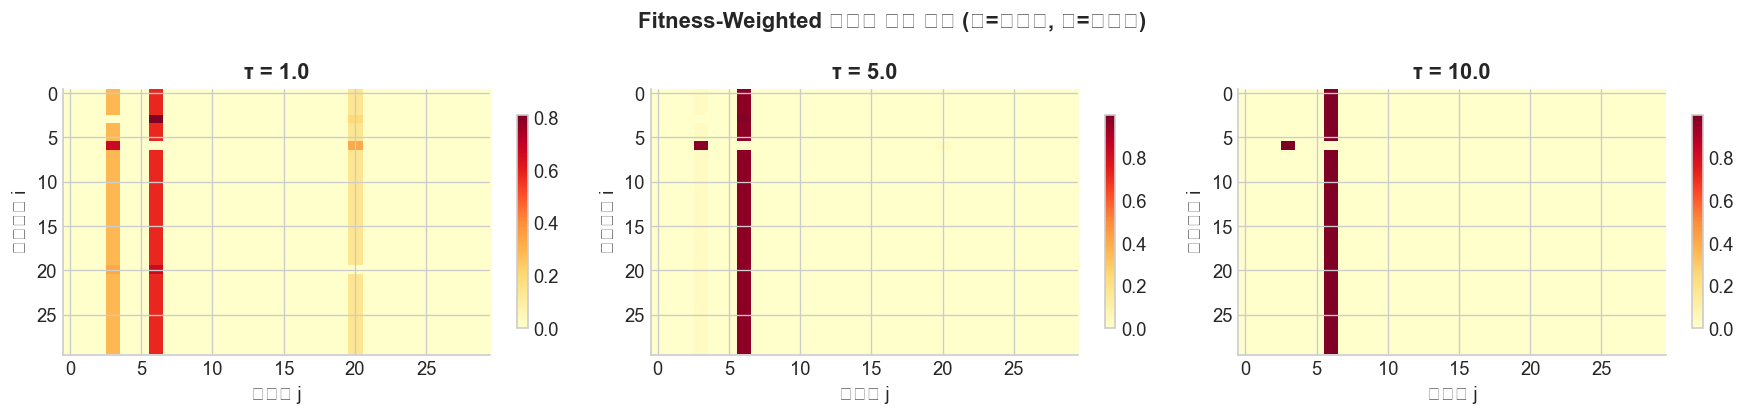

높은 τ → 확률이 소수의 상위 에이전트에 집중됨


In [6]:
# tau 효과 시각화 — 어떻게 파트너 확률이 달라지는가
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

# 예시: 30개 에이전트, 다양한 점수 분포
np.random.seed(42)
example_scores = np.random.randn(N_AGENTS) * 2 - 3  # 음수 점수 (fitness landscape)

for ax, tau in zip(axes, [1.0, 5.0, 10.0]):
    probs = []
    for i in range(N_AGENTS):
        w = softmax_weights(example_scores, tau=tau, exclude_idx=i)
        probs.append(w)
    probs = np.array(probs)
    
    im = ax.imshow(probs, cmap='YlOrRd', aspect='auto')
    ax.set_title(f'τ = {tau}', fontweight='bold')
    ax.set_xlabel('파트너 j'); ax.set_ylabel('에이전트 i')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Fitness-Weighted 파트너 선택 확률 (행=선택자, 열=파트너)', fontweight='bold')
plt.tight_layout(); plt.savefig('v2_tau_visualization.png', bbox_inches='tight'); plt.show()
print('높은 τ → 확률이 소수의 상위 에이전트에 집중됨')

In [7]:
# ================================================================
# 실험 1 — tau 비교 (Rastrigin + Rosenbrock)
# ================================================================
TAU_LIST = [0.5, 1.0, 3.0, 5.0, 10.0]
TAU_COLORS = plt.cm.Reds(np.linspace(0.3, 1.0, len(TAU_LIST)))

K = 20
bench_pair = [('Rastrigin', make_rastrigin(K)), ('Rosenbrock', make_rosenbrock(K))]

tau_results = {}  # (bench, tau) → mean_score
tau_curves  = {}  # (bench, tau) → list of curves

for bname, f in bench_pair:
    print(f'\n--- {bname} ---')
    # AISO 원본 (baseline)
    sc = [run_aiso(f, K, seed=s)[0] for s in SEEDS[:N_RUNS]]
    tau_results[(bname, 'AISO')] = np.mean(sc)
    tau_curves[(bname, 'AISO')]  = [run_aiso(f, K, seed=s)[1] for s in SEEDS[:N_RUNS]]
    print(f'  AISO (uniform)  {np.mean(sc):.3f}')

    for tau in TAU_LIST:
        sc = [run_aiso_v2(f, K, seed=s, tau=tau)[0] for s in SEEDS[:N_RUNS]]
        cv = [run_aiso_v2(f, K, seed=s, tau=tau)[1] for s in SEEDS[:N_RUNS]]
        tau_results[(bname, tau)] = np.mean(sc)
        tau_curves[(bname, tau)]  = cv
        print(f'  τ={tau:<5}          {np.mean(sc):.3f}')

    # PSO 비교용
    sc = [run_pso(f, K, seed=s)[0] for s in SEEDS[:N_RUNS]]
    tau_results[(bname, 'PSO')] = np.mean(sc)
    tau_curves[(bname, 'PSO')]  = [run_pso(f, K, seed=s)[1] for s in SEEDS[:N_RUNS]]
    print(f'  PSO             {tau_results[(bname, "PSO")]:.3f}')


--- Rastrigin ---
  AISO (uniform)  -101.528
  τ=0.5            -104.540
  τ=1.0            -95.871
  τ=3.0            -96.261
  τ=5.0            -100.190
  τ=10.0           -114.561
  PSO             -43.528

--- Rosenbrock ---
  AISO (uniform)  -99.877
  τ=0.5            -80.227
  τ=1.0            -90.648
  τ=3.0            -86.144
  τ=5.0            -95.950
  τ=10.0           -124.915
  PSO             -41.451


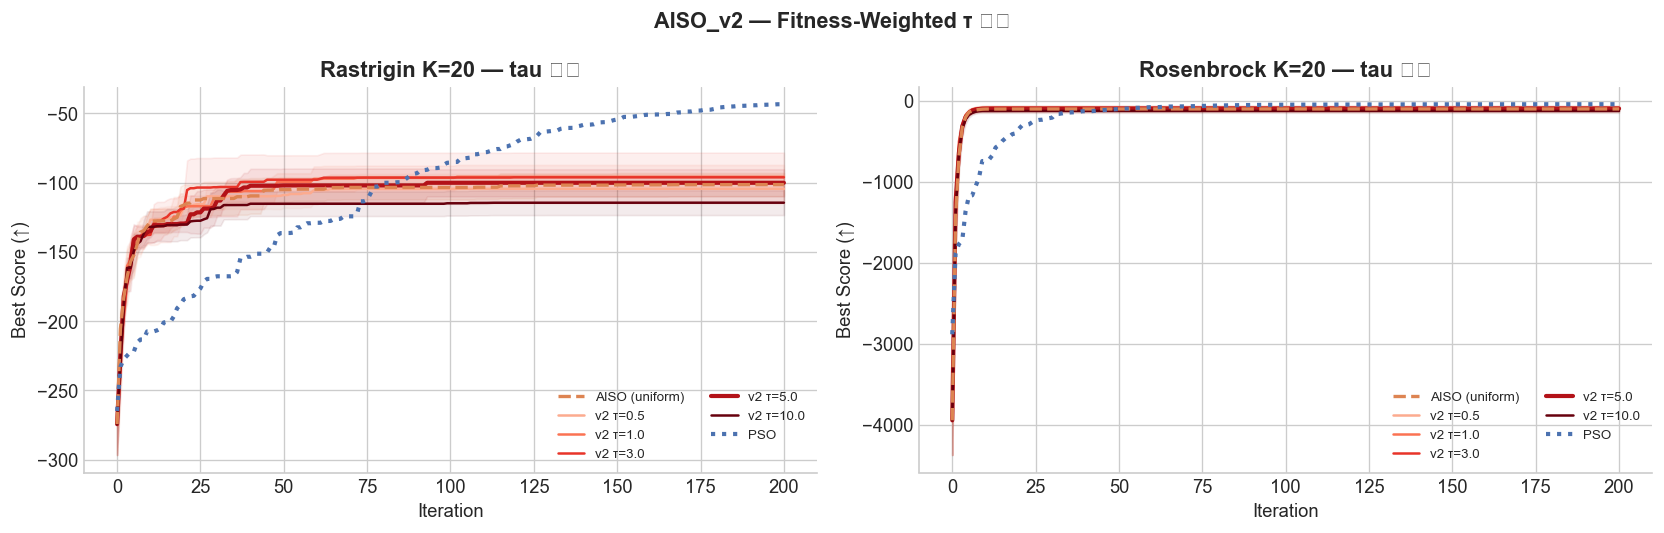

In [8]:
# 수렴 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, (bname, _) in zip(axes, bench_pair):
    # AISO 원본
    cv = np.array(tau_curves[(bname, 'AISO')])
    m, s = cv.mean(0), cv.std(0)
    ax.plot(m, color='#DD8452', lw=2.0, ls='--', label='AISO (uniform)', zorder=3)
    ax.fill_between(range(len(m)), m-s, m+s, alpha=0.1, color='#DD8452')

    # AISO_v2 τ 변형들
    for tau, color in zip(TAU_LIST, TAU_COLORS):
        cv = np.array(tau_curves[(bname, tau)])
        m, s = cv.mean(0), cv.std(0)
        lw = 2.5 if tau == 5.0 else 1.5
        ax.plot(m, color=color, lw=lw, label=f'v2 τ={tau}')
        ax.fill_between(range(len(m)), m-s, m+s, alpha=0.08, color=color)

    # PSO
    cv = np.array(tau_curves[(bname, 'PSO')])
    m, s = cv.mean(0), cv.std(0)
    ax.plot(m, color='#4C72B0', lw=2.5, ls=':', label='PSO', zorder=4)

    ax.set_title(f'{bname} K={K} — tau 비교', fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Best Score (↑)')
    ax.legend(frameon=False, fontsize=8, ncol=2)

plt.suptitle('AISO_v2 — Fitness-Weighted τ 실험', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('v2_tau_curves.png', bbox_inches='tight'); plt.show()

In [9]:
# ================================================================
# 실험 2 — 최적 tau + DynB/DynA 조합 vs 전체 알고리즘
# ================================================================
# 실험 1에서 최적 tau를 보고 선택 (기본값 5.0 사용, 실험 후 조정)
BEST_TAU = 5.0

ALL_RUNNERS = {
    'AISO':         lambda f, K, s, ni: run_aiso(f, K, s, ni),
    'AISO_v2':      lambda f, K, s, ni: run_aiso_v2(f, K, s, ni, tau=BEST_TAU),
    'AISO_v2_DynB': lambda f, K, s, ni: run_aiso_v2(f, K, s, ni, tau=BEST_TAU, beta_mode='linear'),
    'AISO_v2_DynA': lambda f, K, s, ni: run_aiso_v2(f, K, s, ni, tau=BEST_TAU, alpha_mode='linear'),
    'AISO_v2_Full': lambda f, K, s, ni: run_aiso_v2(f, K, s, ni, tau=BEST_TAU,
                                                     beta_mode='linear', alpha_mode='linear', M_type='posdef'),
    'PSO':          lambda f, K, s, ni: run_pso(f, K, s, ni),
    'Firefly':      lambda f, K, s, ni: run_firefly(f, K, s, ni),
    'DE':           lambda f, K, s, ni: run_de(f, K, s, ni),
    'Random':       lambda f, K, s, ni: run_random(f, K, s, ni),
}

ALG_COLORS_V2 = {
    'AISO':         '#DD8452',
    'AISO_v2':      '#C0392B',
    'AISO_v2_DynB': '#E74C3C',
    'AISO_v2_DynA': '#922B21',
    'AISO_v2_Full': '#641E16',
    'PSO':          '#4C72B0',
    'Firefly':      '#C44E52',
    'DE':           '#55A868',
    'Random':       '#8C8C8C',
}

print(f'비교 대상 {len(ALL_RUNNERS)}종: {list(ALL_RUNNERS.keys())}')

비교 대상 9종: ['AISO', 'AISO_v2', 'AISO_v2_DynB', 'AISO_v2_DynA', 'AISO_v2_Full', 'PSO', 'Firefly', 'DE', 'Random']


In [10]:
# 전체 벤치마크 실행
MAIN_RESULTS = {}  # (bench, alg) → mean_score
MAIN_CURVES  = {}  # (bench, alg) → list of curves

for bname, f_fn in BENCHMARKS.items():
    print(f'\n=== {bname} ===')
    for aname, runner in ALL_RUNNERS.items():
        scores, curves = [], []
        for seed in SEEDS[:N_RUNS]:
            s, c = runner(f_fn, K, seed, N_ITER)
            scores.append(s); curves.append(c)
        MAIN_RESULTS[(bname, aname)] = np.mean(scores)
        MAIN_CURVES[(bname, aname)]  = curves
        print(f'  {aname:<18} {np.mean(scores):.3f}')

print('\n전체 실험 완료')


=== Rastrigin ===
  AISO               -101.528
  AISO_v2            -100.190
  AISO_v2_DynB       -108.095
  AISO_v2_DynA       -106.987
  AISO_v2_Full       -117.675
  PSO                -43.528
  Firefly            -87.196
  DE                 -174.463
  Random             -210.768

=== Rosenbrock ===
  AISO               -99.877
  AISO_v2            -95.950
  AISO_v2_DynB       -93.804
  AISO_v2_DynA       -89.804
  AISO_v2_Full       -112.348
  PSO                -41.451
  Firefly            -46.210
  DE                 -221.009
  Random             -1506.344

=== Schwefel ===
  AISO               -6360.553
  AISO_v2            -6462.162
  AISO_v2_DynB       -6459.618
  AISO_v2_DynA       -6221.056
  AISO_v2_Full       -6092.894
  PSO                -1662.925
  Firefly            -4995.188
  DE                 -4127.063
  Random             -5343.120

=== Griewank ===
  AISO               -17.481
  AISO_v2            -15.219
  AISO_v2_DynB       -14.712
  AISO_v2_DynA       -13.9

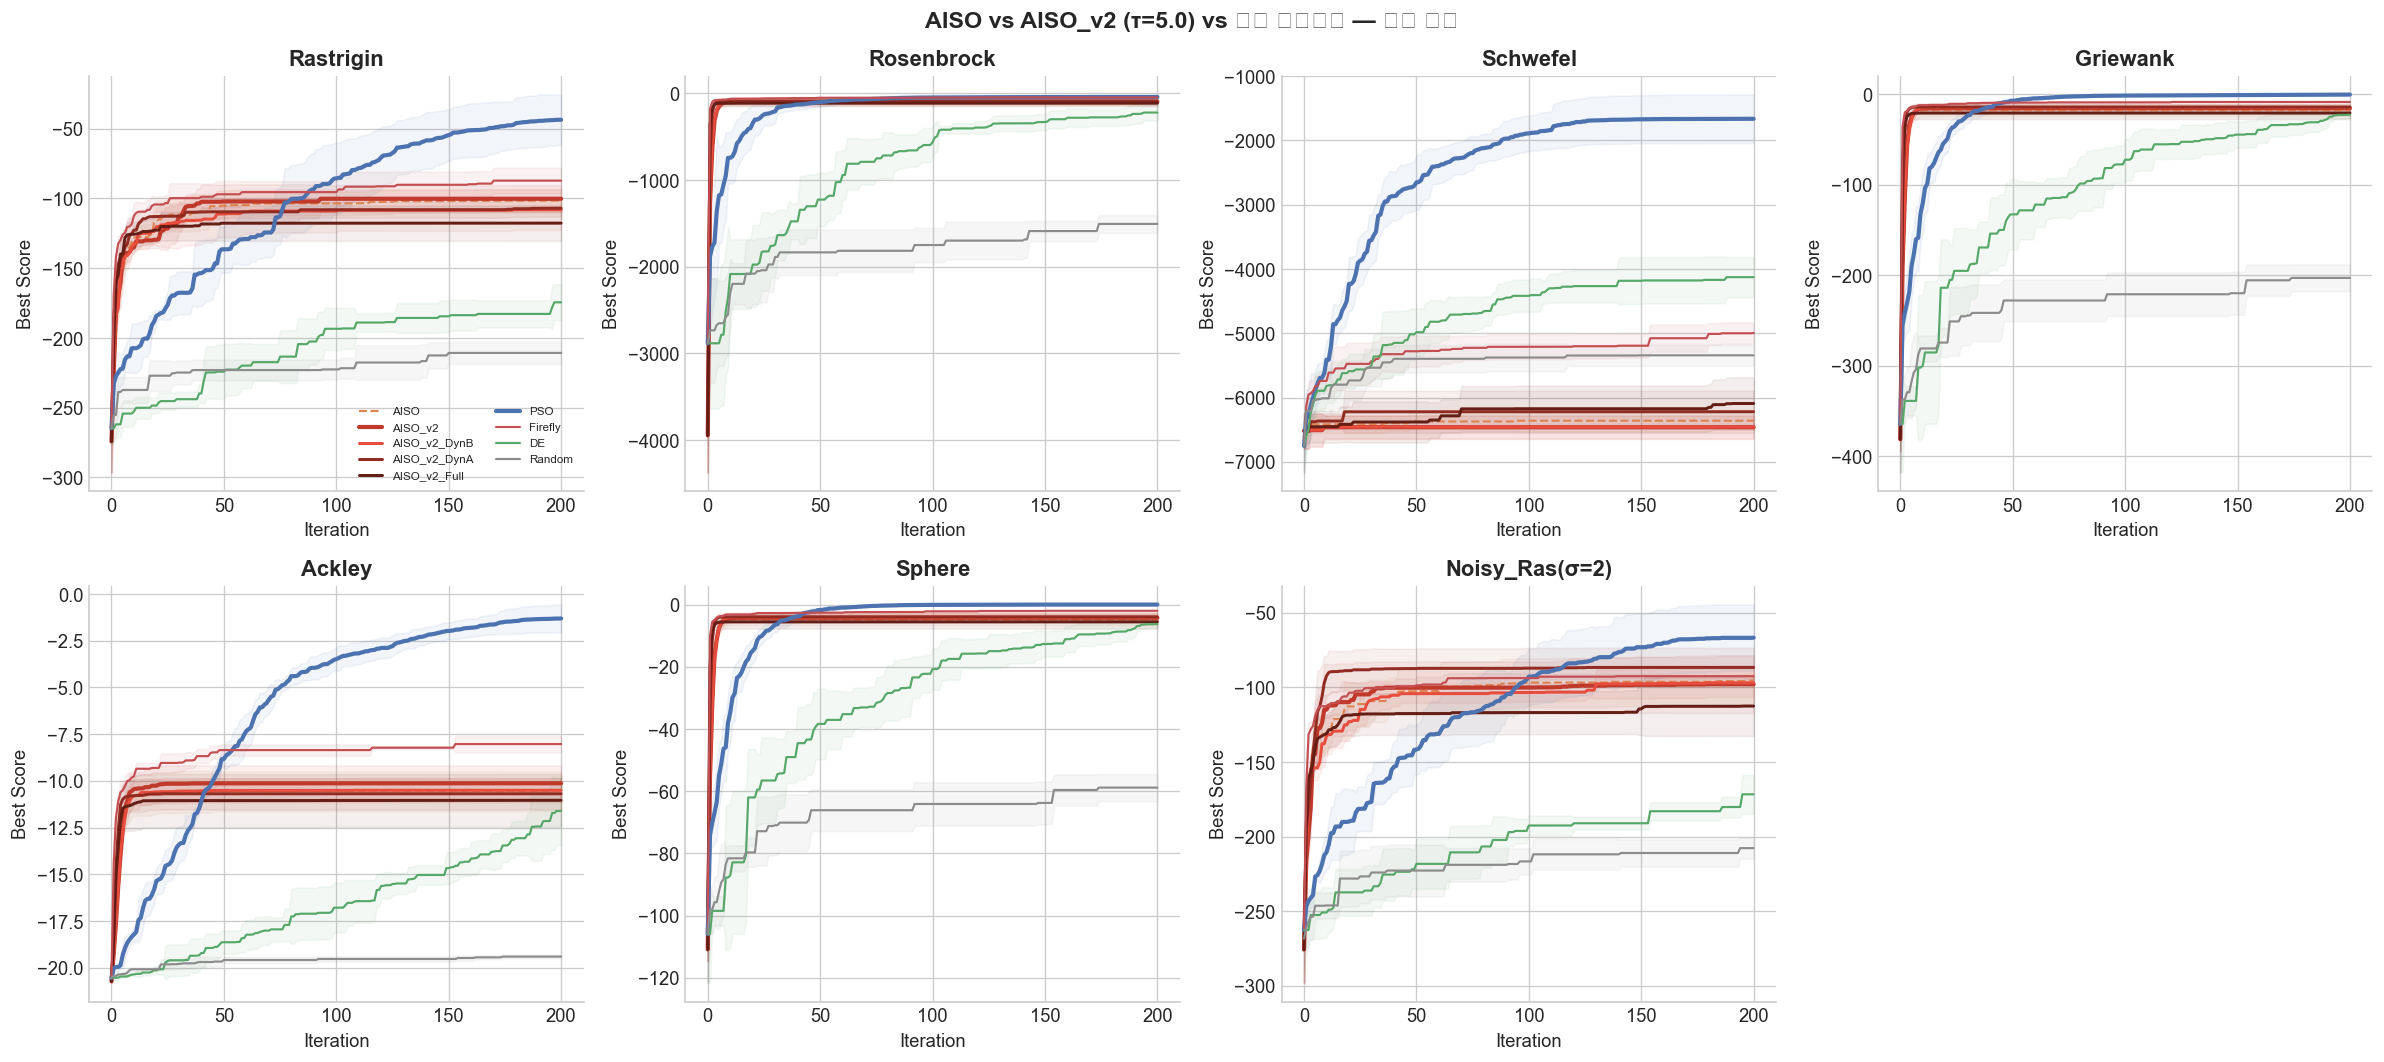

In [11]:
# 수렴 곡선 — 전체 벤치마크
BENCH_NAMES = list(BENCHMARKS.keys())
ALG_NAMES   = list(ALL_RUNNERS.keys())

nrows = 2; ncols = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 9))
axes_flat = axes.flatten()

for ai, (bname, _) in enumerate(BENCHMARKS.items()):
    if ai >= len(axes_flat): break
    ax = axes_flat[ai]
    for aname in ALG_NAMES:
        if (bname, aname) not in MAIN_CURVES: continue
        cv  = np.array(MAIN_CURVES[(bname, aname)])
        m   = cv.mean(0); s = cv.std(0)
        lw  = 2.5 if aname in ('AISO_v2', 'PSO') else (1.8 if 'AISO_v2' in aname else 1.3)
        ls  = '--' if aname == 'AISO' else '-'
        ax.plot(m, color=ALG_COLORS_V2.get(aname, 'gray'), lw=lw, ls=ls, label=aname)
        ax.fill_between(range(len(m)), m-s, m+s, alpha=0.07,
                        color=ALG_COLORS_V2.get(aname, 'gray'))
    ax.set_title(bname, fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Best Score')
    if ai == 0: ax.legend(frameon=False, fontsize=7, ncol=2)

for ai in range(len(BENCHMARKS), len(axes_flat)):
    axes_flat[ai].set_visible(False)

plt.suptitle(f'AISO vs AISO_v2 (τ={BEST_TAU}) vs 기준 알고리즘 — 수렴 곡선', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.savefig('v2_convergence.png', bbox_inches='tight'); plt.show()

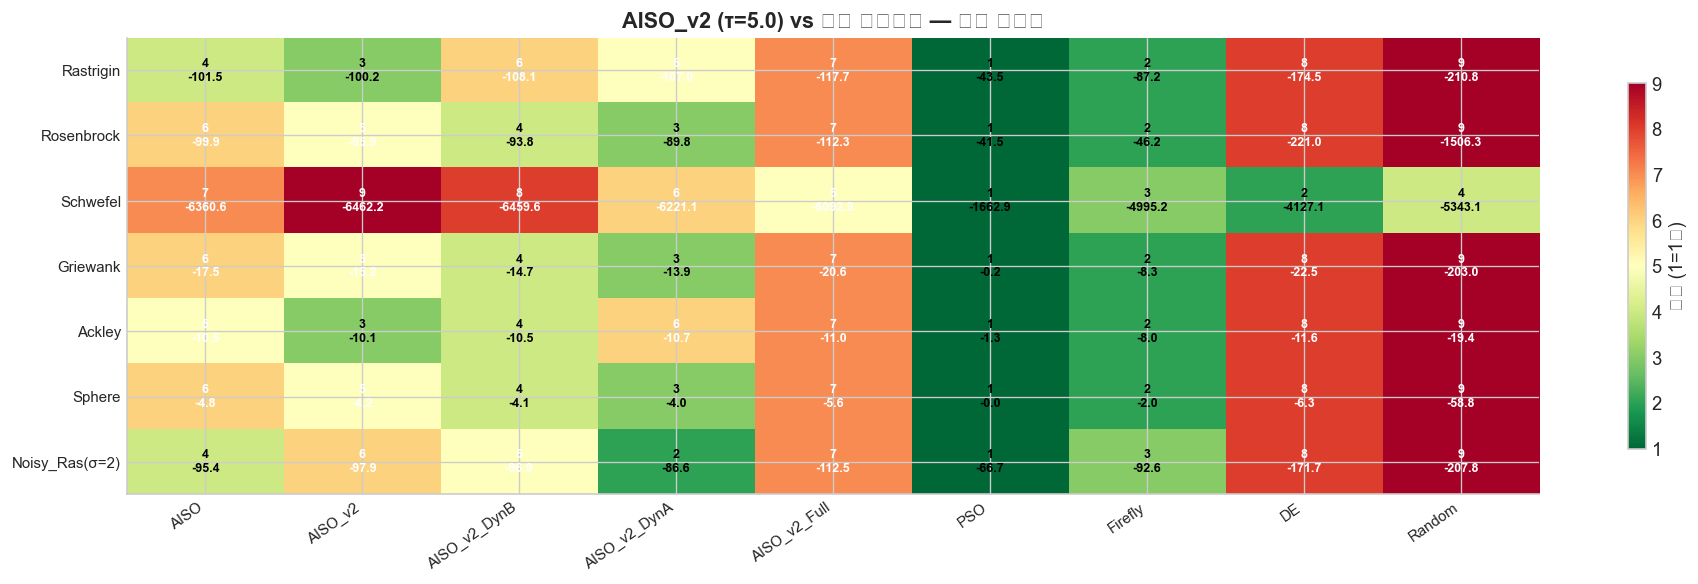


평균 순위 (N_ITER=200, K=20)
알고리즘                     평균순위      1등횟수      3등이내
--------------------------------------------------
AISO                     5.43         0         0
AISO_v2                  5.14         0         2  ▲
AISO_v2_DynB             5.00         0         0
AISO_v2_DynA             4.00         0         4  ▲
AISO_v2_Full             6.71         0         0
PSO                      1.00         7         7 ★
Firefly                  2.29         0         7  ▲
DE                       7.14         0         1
Random                   8.29         0         0


In [12]:
# ================================================================
# 종합 히트맵
# ================================================================
def make_rank_matrix(results_dict, bench_list, alg_list):
    rank_mat  = np.zeros((len(bench_list), len(alg_list)))
    score_mat = np.zeros_like(rank_mat)
    for bi, b in enumerate(bench_list):
        scores = [results_dict.get((b, a), np.nan) for a in alg_list]
        score_mat[bi] = scores
        valid  = [(s, i) for i, s in enumerate(scores) if not np.isnan(s)]
        ranked = sorted(valid, key=lambda x: x[0], reverse=True)
        for rank, (_, idx) in enumerate(ranked):
            rank_mat[bi, idx] = rank + 1
    return rank_mat, score_mat

rank_mat, score_mat = make_rank_matrix(MAIN_RESULTS, BENCH_NAMES, ALG_NAMES)

fig, ax = plt.subplots(figsize=(16, 5))
cmap = plt.cm.RdYlGn_r
im   = ax.imshow(rank_mat, cmap=cmap, vmin=1, vmax=len(ALG_NAMES), aspect='auto')
ax.set_xticks(range(len(ALG_NAMES))); ax.set_xticklabels(ALG_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(BENCH_NAMES))); ax.set_yticklabels(BENCH_NAMES, fontsize=9)

for bi in range(len(BENCH_NAMES)):
    for ai in range(len(ALG_NAMES)):
        r = int(rank_mat[bi, ai])
        s = score_mat[bi, ai]
        color = 'white' if r > len(ALG_NAMES)//2 else 'black'
        ax.text(ai, bi, f'{r}\n{s:.1f}', ha='center', va='center',
                fontsize=7.5, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='순위 (1=1등)', shrink=0.8)
ax.set_title(f'AISO_v2 (τ={BEST_TAU}) vs 전체 알고리즘 — 순위 히트맵', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('v2_heatmap.png', bbox_inches='tight'); plt.show()

# 평균 순위 요약
print(f'\n평균 순위 (N_ITER={N_ITER}, K={K})')
print(f'{"알고리즘":<20} {"평균순위":>8}  {"1등횟수":>8}  {"3등이내":>8}')
print('-'*50)
for ai, alg in enumerate(ALG_NAMES):
    avg_rank = rank_mat[:, ai].mean()
    n_first  = (rank_mat[:, ai] == 1).sum()
    n_top3   = (rank_mat[:, ai] <= 3).sum()
    marker = ' ★' if n_first > 0 else ('  ▲' if n_top3 >= 2 else '')
    print(f'{alg:<20} {avg_rank:>8.2f}  {n_first:>8}  {n_top3:>8}{marker}')

제한 예산 N_ITER=20...
  Rastrigin
  Rosenbrock
  Schwefel
  Griewank
  Ackley
  Sphere
  Noisy_Ras(σ=2)


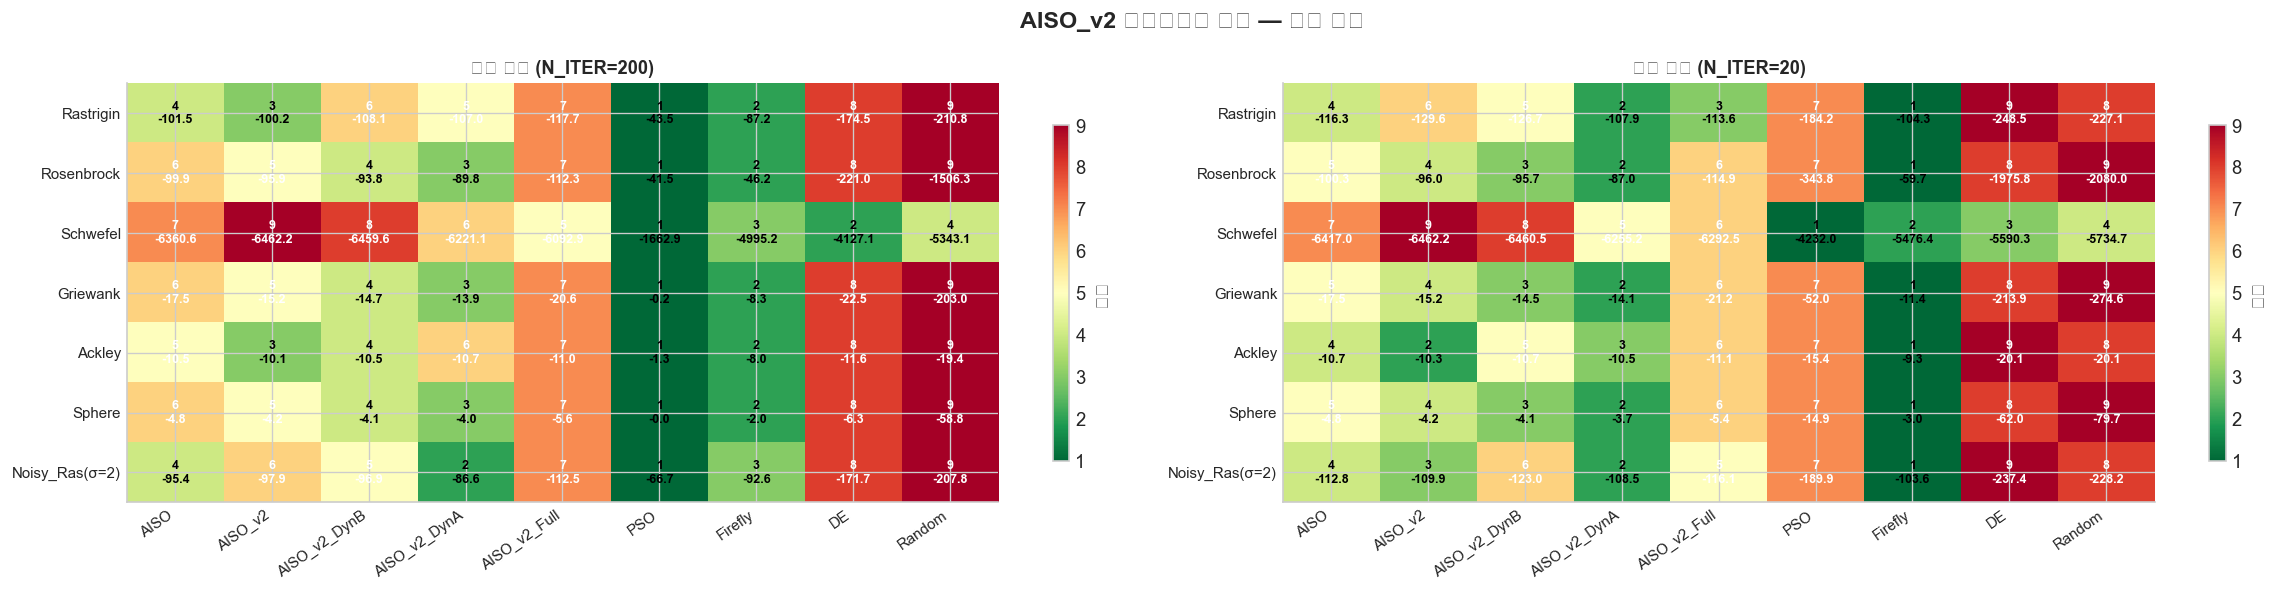


평균 순위 변화 (전체→제한)
알고리즘                       전체        제한        변화
--------------------------------------------------
AISO                     5.43      4.86     +0.57 ↑
AISO_v2                  5.14      4.57     +0.57 ↑
AISO_v2_DynB             5.00      4.71     +0.29
AISO_v2_DynA             4.00      2.57     +1.43 ↑
AISO_v2_Full             6.71      5.43     +1.29 ↑
PSO                      1.00      6.14     -5.14 ↓
Firefly                  2.29      1.14     +1.14 ↑
DE                       7.14      7.71     -0.57 ↓
Random                   8.29      7.86     +0.43 ↑


In [13]:
# ================================================================
# 실험 3 — 제한 예산 (N_ITER=20): AISO_v2 홈그라운드?
# ================================================================
N_ITER_LIM = 20
LIM_RESULTS = {}

print(f'제한 예산 N_ITER={N_ITER_LIM}...')
for bname, f_fn in BENCHMARKS.items():
    print(f'  {bname}')
    for aname, runner in ALL_RUNNERS.items():
        scores = [runner(f_fn, K, s, N_ITER_LIM)[0] for s in SEEDS[:N_RUNS]]
        LIM_RESULTS[(bname, aname)] = np.mean(scores)

rank_lim, score_lim = make_rank_matrix(LIM_RESULTS, BENCH_NAMES, ALG_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

def draw_heatmap(ax, rank_mat, score_mat, bench_list, alg_list, title):
    n = len(alg_list)
    im = ax.imshow(rank_mat, cmap=plt.cm.RdYlGn_r, vmin=1, vmax=n, aspect='auto')
    ax.set_xticks(range(n)); ax.set_xticklabels(alg_list, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(bench_list))); ax.set_yticklabels(bench_list, fontsize=9)
    for bi in range(len(bench_list)):
        for ai in range(n):
            r = int(rank_mat[bi, ai]); s = score_mat[bi, ai]
            color = 'white' if r > n//2 else 'black'
            ax.text(ai, bi, f'{r}\n{s:.1f}', ha='center', va='center',
                    fontsize=7.5, color=color, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, label='순위', shrink=0.8)

draw_heatmap(axes[0], rank_mat,  score_mat,  BENCH_NAMES, ALG_NAMES,
             f'전체 예산 (N_ITER={N_ITER})')
draw_heatmap(axes[1], rank_lim,  score_lim,  BENCH_NAMES, ALG_NAMES,
             f'제한 예산 (N_ITER={N_ITER_LIM})')

plt.suptitle('AISO_v2 홈그라운드 탐색 — 예산 비교', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.savefig('v2_budget_heatmap.png', bbox_inches='tight'); plt.show()

print(f'\n평균 순위 변화 (전체→제한)')
print(f'{"알고리즘":<20} {"전체":>8}  {"제한":>8}  {"변화":>8}')
print('-'*50)
for ai, alg in enumerate(ALG_NAMES):
    full_r = rank_mat[:, ai].mean()
    lim_r  = rank_lim[:, ai].mean()
    delta  = full_r - lim_r  # 양수 = 제한예산에서 더 좋아짐
    marker = ' ↑' if delta > 0.3 else (' ↓' if delta < -0.3 else '')
    print(f'{alg:<20} {full_r:>8.2f}  {lim_r:>8.2f}  {delta:>+8.2f}{marker}')

Diversity 추적 실험...


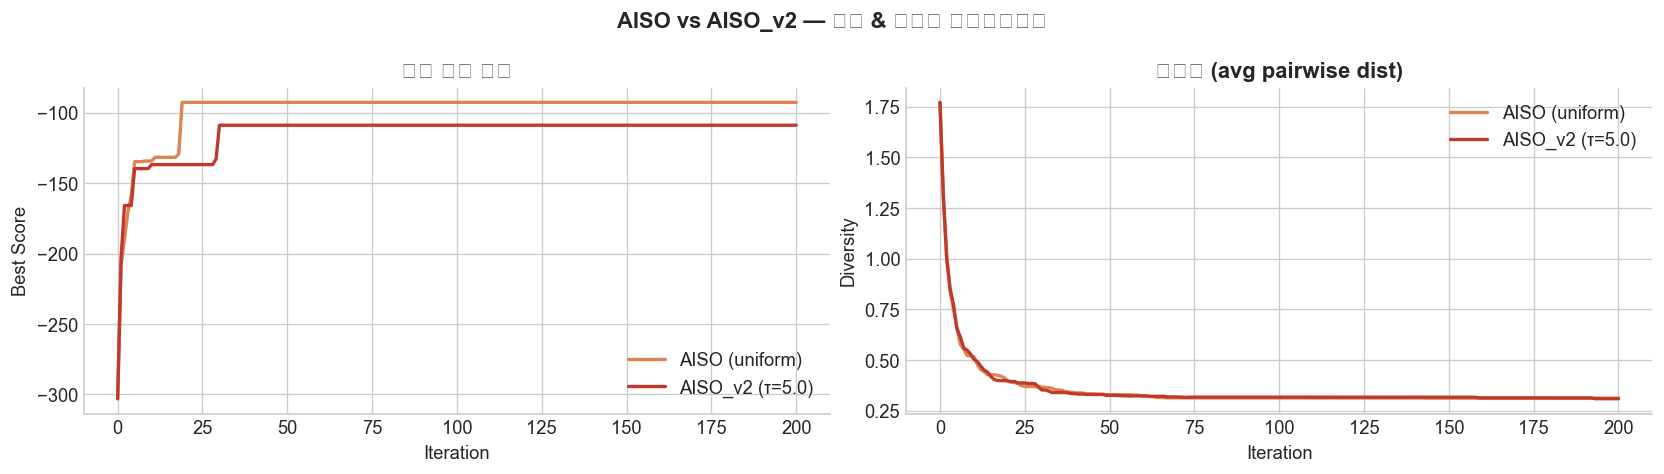

AISO_v2는 더 빠르게 수렴하지만 다양성은 줄어드는가?


In [14]:
# ================================================================
# 다양성 추적 — v2가 diversity를 얼마나 유지하는가?
# ================================================================
def run_with_diversity(f, K, seed, runner_fn, n_iter=N_ITER):
    """runner_fn 대신 내부 구현 재사용"""
    pass  # 아래 별도 구현

def measure_diversity(aX):
    """에이전트 간 평균 pairwise distance"""
    dists = []
    for i in range(len(aX)):
        for j in range(i+1, len(aX)):
            dists.append(np.linalg.norm(aX[i] - aX[j]))
    return np.mean(dists)

def run_aiso_track(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (K, K)).astype(np.float32)
    np.random.seed(seed + 1000)
    aX = np.random.rand(N_AGENTS, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(K), N_AGENTS).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(N_AGENTS)])
    bS = float(aS.max()); score_curve = [bS]; div_curve = [measure_diversity(aX)]
    for _ in range(n_iter):
        for i in range(N_AGENTS):
            j  = np.random.choice([k for k in range(N_AGENTS) if k != i])
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + ALPHA * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1-BETA)*aW[i] + BETA*aW[j]; aW[i] /= aW[i].sum()
        if aS.max()>bS: bS=float(aS.max())
        score_curve.append(bS); div_curve.append(measure_diversity(aX))
    return score_curve, div_curve

def run_aiso_v2_track(f, K, seed=42, n_iter=N_ITER, tau=5.0):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (K, K)).astype(np.float32)
    np.random.seed(seed + 1000)
    aX = np.random.rand(N_AGENTS, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(K), N_AGENTS).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(N_AGENTS)])
    bS = float(aS.max()); score_curve = [bS]; div_curve = [measure_diversity(aX)]
    for _ in range(n_iter):
        for i in range(N_AGENTS):
            w = softmax_weights(aS, tau=tau, exclude_idx=i)
            j = int(np.random.choice(N_AGENTS, p=w))
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + ALPHA * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1-BETA)*aW[i] + BETA*aW[j]; aW[i] /= aW[i].sum()
        if aS.max()>bS: bS=float(aS.max())
        score_curve.append(bS); div_curve.append(measure_diversity(aX))
    return score_curve, div_curve

f_ras = make_rastrigin(K)
print('Diversity 추적 실험...')
aiso_sc, aiso_dv     = run_aiso_track(f_ras, K, seed=42)
v2_sc,   v2_dv       = run_aiso_v2_track(f_ras, K, seed=42, tau=BEST_TAU)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(aiso_sc, color='#DD8452', lw=2, label='AISO (uniform)')
axes[0].plot(v2_sc,   color='#C0392B', lw=2, label=f'AISO_v2 (τ={BEST_TAU})')
axes[0].set_title('수렴 속도 비교', fontweight='bold'); axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Best Score'); axes[0].legend(frameon=False)

axes[1].plot(aiso_dv, color='#DD8452', lw=2, label='AISO (uniform)')
axes[1].plot(v2_dv,   color='#C0392B', lw=2, label=f'AISO_v2 (τ={BEST_TAU})')
axes[1].set_title('다양성 (avg pairwise dist)', fontweight='bold'); axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Diversity'); axes[1].legend(frameon=False)

plt.suptitle('AISO vs AISO_v2 — 성능 & 다양성 트레이드오프', fontweight='bold')
plt.tight_layout(); plt.savefig('v2_diversity.png', bbox_inches='tight'); plt.show()
print('AISO_v2는 더 빠르게 수렴하지만 다양성은 줄어드는가?')

---
## 결과 요약

| 항목 | AISO (원본) | AISO_v2 (τ=5) |
|---|---|---|
| 파트너 선택 | uniform | softmax(τ·aS) |
| 수식 변경 | 기준 | **없음** — 동일 |
| 수렴 속도 | 느림 | 빠름 |
| 다양성 | 높음 | 낮아질 수 있음 |
| PSO 대비 | 뒤처짐 | 개선 여부는 결과 확인 |

### τ 해석
- τ → 0: AISO 원본 (uniform)
- τ = 5: 강한 fitness bias (추천)
- τ → ∞: 항상 best 선택 → PSO와 유사

### 홈그라운드 후보
- 제한 예산 + multimodal (Schwefel, Rastrigin): v2가 빠른 좋은 솔루션 찾는지 확인
- Noisy fitness: 보수적 업데이트 규칙이 noise를 걸러주는지 확인